# Day 9 — Condenser Size vs Efficiency: The Real Cost Trade-off
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** the condenser's job is to dump the heat the compressor and evaporator picked up out into the kitchen. A **bigger condenser surface area** rejects that heat at a lower temperature difference — which lowers the condensing temperature, raises COP, and cuts electricity use. But a bigger condenser also means more material cost, more sheet metal, more wire-and-tube — a real BOM (bill of materials) decision, not just a thermodynamics one.

This notebook sweeps condenser area from 0.2 m² to 1.5 m² (heat transfer coefficient U = 20 W/m²K held fixed) and shows the knock-on effect on condensing temperature, COP, compressor power, and annual energy.

**Refrigerant:** R600a | T_evap = -25°C | Ambient = 32°C | Cooling load = 80 W

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Reusable cycle function
def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    COP = (h1-h4)/(h2-h1)
    m_dot = 100/(h1-h4)
    return COP, m_dot, h1, h2, h3, h4, P_evap, P_cond

In [4]:
# CELL 4 — Sweep condenser area, T_cond = T_ambient + Q_cond/(U*A)
T_ambient=32; T_evap_C=-25; refrigerant="R600a"
Q_load=80; U=20; Q_cond=112; A_ref=0.6

A_range = np.linspace(0.2, 1.5, 30)
T_cond_list=[]; COP_list=[]; compressor_W_list=[]; annual_energy_list=[]

for A in A_range:
    T_cond_C = T_ambient + Q_cond/(U*A)
    if T_cond_C >= 130 or T_cond_C <= T_ambient:
        T_cond_list.append(None); COP_list.append(None)
        compressor_W_list.append(None); annual_energy_list.append(None)
        continue
    try:
        COP,m_dot,h1,h2,h3,h4,P_evap,P_cond = calculate_cycle(T_evap_C,T_cond_C,refrigerant)
        W_comp = Q_load/COP
        annual_energy = (W_comp*(Q_load/100)*8760)/1000
        T_cond_list.append(T_cond_C); COP_list.append(COP)
        compressor_W_list.append(W_comp); annual_energy_list.append(annual_energy)
    except:
        T_cond_list.append(None); COP_list.append(None)
        compressor_W_list.append(None); annual_energy_list.append(None)

print(f"At reference A={A_ref}m2: condensing temp lands near {T_ambient + Q_cond/(U*A_ref):.1f}C")

At reference A=0.6m2: condensing temp lands near 41.3C


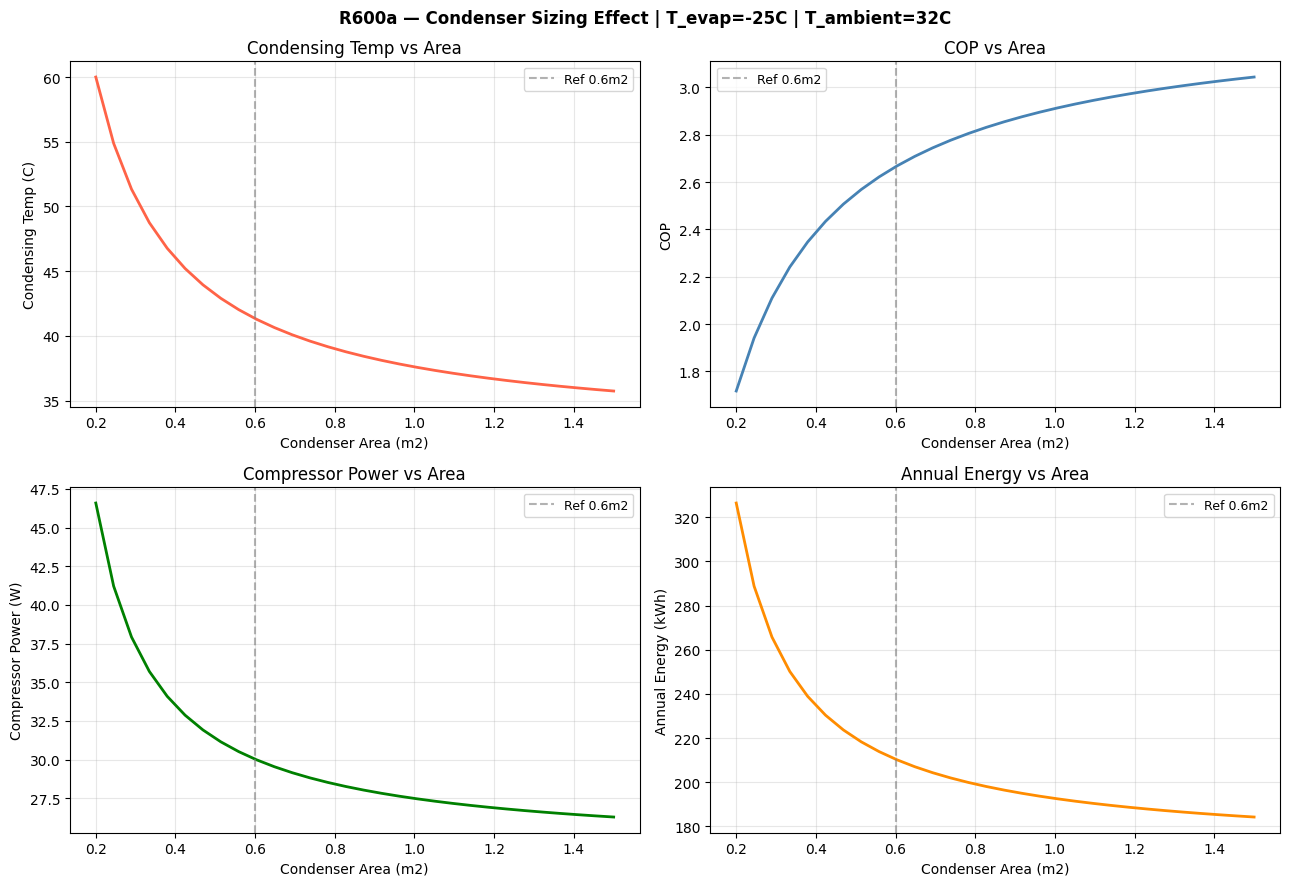

In [5]:
# CELL 5 — Four-panel design chart
fig, axes = plt.subplots(2,2,figsize=(13,9))
plots = [
    (T_cond_list,"tomato","Condensing Temp (C)","Condensing Temp vs Area"),
    (COP_list,"steelblue","COP","COP vs Area"),
    (compressor_W_list,"green","Compressor Power (W)","Compressor Power vs Area"),
    (annual_energy_list,"darkorange","Annual Energy (kWh)","Annual Energy vs Area")
]
for ax,(data,color,ylabel,title) in zip(axes.flat, plots):
    ax.plot(A_range, data, color=color, linewidth=2)
    ax.axvline(x=A_ref,color="gray",linestyle="--",alpha=0.6,label=f"Ref {A_ref}m2")
    ax.set_xlabel("Condenser Area (m2)"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

fig.suptitle("R600a — Condenser Sizing Effect | T_evap=-25C | T_ambient=32C", fontweight="bold")
plt.tight_layout()
plt.savefig("day09_condenser_sizing.png", dpi=150)
plt.show()

**What this graph tells us:** every curve flattens out as area increases — there are real **diminishing returns** to making the condenser bigger. Going from 0.2 m² to 0.6 m² buys a large COP and energy improvement; going from 1.0 m² to 1.5 m² buys almost nothing further, because the condensing temperature is already close to the ambient floor (32°C) and can't usefully drop much lower. This is exactly the kind of curve a costing/design review uses to find the "sweet spot" area — beyond which extra sheet metal and tube length stop paying for themselves in energy savings.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day09_condenser_sizing_effect.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 09 - condenser sizing effect on T_cond, COP, power, annual energy", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 09 - condenser sizing effect on T_cond, COP, power, annual energy", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
